In [ ]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import yfinance as yf
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 參數設定
# ==========================================
TARGET_COL = 'Target_DGS2'
TEST_START_DATE = '2018-01-01'  
LOOKBACK_WINDOW = 24            
TOP_N = 5                       

# ==========================================
# 2. 變數嚴格分類 (100% 全覆蓋修正版)
# ==========================================

# A. 連續性變數 (市場價格/每日變動) -> 預測時 FFill
CONTINUOUS_VARS = [
    # 利率與債券
    'Yield_10Y', 'Yield_Spread_10Y2Y', 'Fed_Funds', 'Inflation_Exp', 'Financial_Cond',
    # 資產價格
    'Oil_WTI', 'Copper', 'Dollar_Index', 'S&P500', 'Copper_Oil_Ratio',
    # Fed 資產負債表 (雖是週更，但視為存量水位)
    'Fed_Assets' 
]

# B. 衝擊性變數 (經濟數據/定期公佈) -> 預測時 Decay
SHOCK_VARS = [
    # 通膨類
    'Core_PCE', 'PCE_Price', 'CPI', 'Core_CPI', 'PPI',
    # 就業類
    'Unemployment', 'Nonfarm_Payrolls', 'Hourly_Earnings', 'Jobless_Claims', 'JOLTS_Openings', 'Labor_Partic',
    # 景氣與消費
    'Real_GDP', 'Ind_Production', 'Retail_Sales', 'Debt_to_GDP',
    # 情緒類
    'Mich_Sentiment', 'FOMC_Sentiment'
]

# ==========================================
# 3. 宏觀指標清單 (下載用)
# ==========================================
MACRO_INDICATORS = {
    # 通膨
    'Core_PCE': {'ticker': 'PCEPILFE', 'source': 'fred'},
    'PCE_Price': {'ticker': 'PCEPI', 'source': 'fred'},
    'CPI': {'ticker': 'CPIAUCSL', 'source': 'fred'},
    'Core_CPI': {'ticker': 'CPILFESL', 'source': 'fred'},
    'PPI': {'ticker': 'PPIACO', 'source': 'fred'},
    'Inflation_Exp': {'ticker': 'T10YIE', 'source': 'fred'},
    # 就業
    'Unemployment': {'ticker': 'UNRATE', 'source': 'fred'},
    'Nonfarm_Payrolls': {'ticker': 'PAYEMS', 'source': 'fred'},
    'Hourly_Earnings': {'ticker': 'CES0500000003', 'source': 'fred'},
    'Jobless_Claims': {'ticker': 'ICSA', 'source': 'fred'},
    'JOLTS_Openings': {'ticker': 'JTSJOL', 'source': 'fred'},
    'Labor_Partic': {'ticker': 'CIVPART', 'source': 'fred'},
    # 景氣
    'Real_GDP': {'ticker': 'GDPC1', 'source': 'fred'},
    'Ind_Production': {'ticker': 'INDPRO', 'source': 'fred'},
    'Retail_Sales': {'ticker': 'RSAFS', 'source': 'fred'},
    'Debt_to_GDP': {'ticker': 'GFDEGDQ188S', 'source': 'fred'},
    # 情緒與金融條件
    'Mich_Sentiment': {'ticker': 'UMCSENT', 'source': 'fred'},
    'Financial_Cond': {'ticker': 'NFCI', 'source': 'fred'},
    # 市場價格
    'Yield_10Y': {'ticker': 'DGS10', 'source': 'fred'},
    'Yield_Spread_10Y2Y': {'ticker': 'T10Y2Y', 'source': 'fred'},
    'Fed_Funds': {'ticker': 'DFF', 'source': 'fred'},
    'Fed_Assets': {'ticker': 'WALCL', 'source': 'fred'},
    'Oil_WTI': {'ticker': 'CL=F', 'source': 'yahoo'},
    'Copper': {'ticker': 'HG=F', 'source': 'yahoo'},
    'Dollar_Index': {'ticker': 'DX-Y.NYB', 'source': 'yahoo'},
    'S&P500': {'ticker': '^GSPC', 'source': 'yahoo'},
}

EVENT_DATES_MAP = {} 

def fetch_and_process_data(start_date='2015-01-01'):
    global EVENT_DATES_MAP
    print(f">>> [Init] 建立數據庫 (含完整分類檢查)...")
    
    # 1. Target
    try:
        target = web.DataReader('DGS2', 'fred', start=start_date)
        target.columns = [TARGET_COL]
        full_idx = pd.date_range(start=target.index.min(), end=target.index.max(), freq='D')
        df_pool = target.reindex(full_idx).ffill()
    except: return pd.DataFrame()

    # 2. Macro Indicators
    for name, info in tqdm(MACRO_INDICATORS.items(), desc="Fetching"):
        try:
            if info['source'] == 'fred':
                s = web.DataReader(info['ticker'], 'fred', start=start_date).iloc[:, 0]
            elif info['source'] == 'yahoo':
                d = yf.download(info['ticker'], start=start_date, progress=False)
                s = d['Adj Close'] if 'Adj Close' in d.columns else d['Close']
            
            valid_dates = set(s.dropna().index.normalize().tolist())
            EVENT_DATES_MAP[name] = valid_dates
            df_pool[name] = s.reindex(df_pool.index).ffill()
        except: continue
            
    # 3. FOMC (Local File)
    fomc_file = r"data\processed\FOMC_Analysis_DirectionLocked.csv"
    if os.path.exists(fomc_file):
        try:
            df_fomc = pd.read_csv(fomc_file)
            df_fomc['Date'] = pd.to_datetime(df_fomc['Date'])
            fomc_dates = set(df_fomc['Date'].dt.normalize().tolist())
            EVENT_DATES_MAP['FOMC_Sentiment'] = fomc_dates
            df_fomc = df_fomc.set_index('Date').sort_index()
            if 'Score' in df_fomc.columns:
                df_pool['FOMC_Sentiment'] = df_fomc['Score'].reindex(df_pool.index).ffill()
                print(f"    📅 FOMC 數據已載入")
        except: pass

    # 4. Copper Oil Ratio
    if 'Copper' in df_pool.columns and 'Oil_WTI' in df_pool.columns:
        df_pool['Copper_Oil_Ratio'] = df_pool['Copper'] / df_pool['Oil_WTI']
        if 'Copper' in EVENT_DATES_MAP and 'Oil_WTI' in EVENT_DATES_MAP:
            EVENT_DATES_MAP['Copper_Oil_Ratio'] = EVENT_DATES_MAP['Copper'].union(EVENT_DATES_MAP['Oil_WTI'])

    # ★ 5. 防呆檢查：確保所有下載的變數都有被分類 ★
    downloaded_vars = set(df_pool.columns) - {TARGET_COL}
    classified_vars = set(CONTINUOUS_VARS) | set(SHOCK_VARS)
    
    missing_vars = downloaded_vars - classified_vars
    if missing_vars:
        print(f"\n⚠️ 警告：以下變數未被分類，將預設為 Continuous (FFill)：")
        print(f"   {missing_vars}")
        # 自動補入 Continuous 以免報錯
        CONTINUOUS_VARS.extend(list(missing_vars))
    else:
        print(f"\n✅ 變數分類檢查通過：100% 覆蓋。")

    return df_pool.dropna()

# 執行準備
data_pool = fetch_and_process_data(start_date='2015-01-01')

>>> [Init] 建立數據庫 (含完整分類檢查)...


Fetching: 100%|██████████| 26/26 [00:41<00:00,  1.62s/it]

    📅 FOMC 數據已載入

✅ 變數分類檢查通過：100% 覆蓋。



>>> [Step 2] 啟動「預測未來」模式 (Horizon: 126 天)...
    運算裝置: CUDA
    本次預測基準日: 2025-12-05
    預測範圍: 2025-12-06 ~ 2026-04-10
    正在準備 TimesFM 輸入數據...
    批次數據形狀: (1, 512)
    🚀 正在執行 TimesFM 單次推理 (Baseline)...
Downloaded.
    🔧 正在執行 Ridge 動態修正 (CPU Fast Loop)...


Feature Generation: 100%|██████████| 1/1 [00:00<00:00, 333.36it/s]

    ✅ Ridge 修正完成。

📊 === 未來預測結果 (TimesFM Hybrid) ===
2025-12-06    3.556518
2025-12-07    3.556429
2025-12-08    3.552787
2025-12-09    3.559498
2025-12-10    3.554704
Freq: D
...
2026-04-06    4.240364
2026-04-07    4.249697
2026-04-08    4.248673
2026-04-09    4.241529
2026-04-10    4.244795
Freq: D


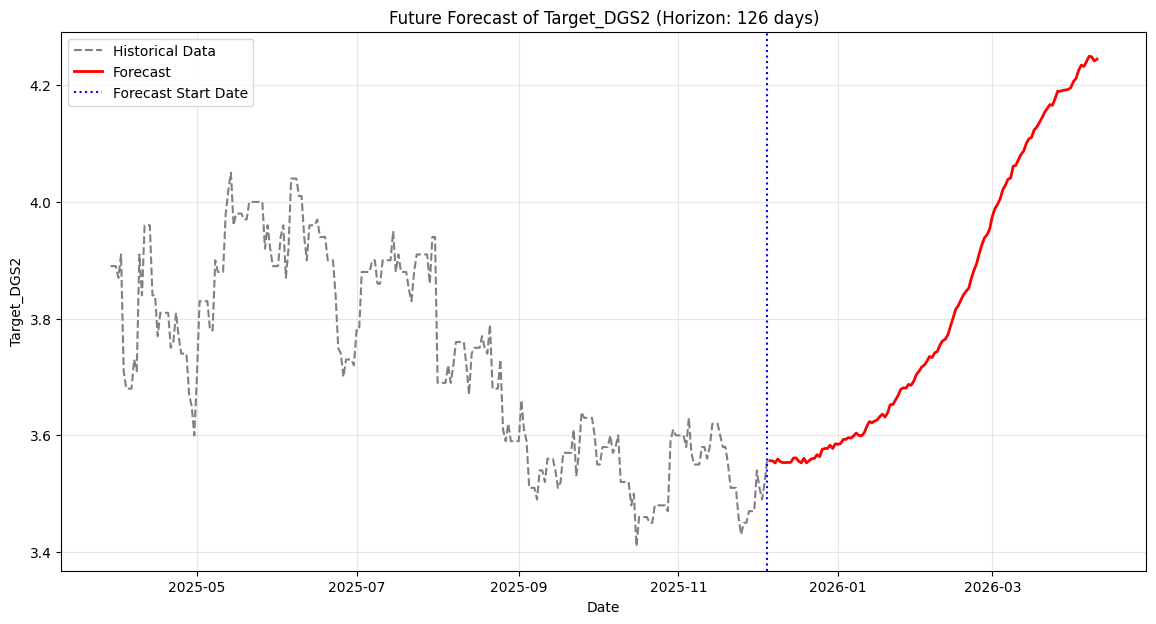

In [2]:
import torch
import timesfm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta, date
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
# 預測未來不需要 mean_absolute_error，因此移除
from tqdm import tqdm

# ==========================================
# 參數確認
# ==========================================
# 這些變數需要您在程式碼執行前定義
# TARGET_COL = '您的目標欄位名稱'
# CONTINUOUS_VARS = ['連續變數欄位名稱列表'] # 假設您的連續變數列表
# data_pool = 您的所有歷史數據 DataFrame
# EVENT_DATES_MAP = 您的事件日期字典

CORR_THRESHOLD = 0.7
HORIZON_LEN = 126 # 預測的未來天數
LOOKBACK_WINDOW = 24
CONTEXT_LEN = 512

# ==========================================
# 3. 智能生成器 (Smart Decay) - 保留
# ==========================================
class SmartDecayGenerator:
    @staticmethod
    def generate_future_path(last_val, steps, col_name, method='cos'):
        t = np.arange(steps)
        # 假設 CONTINUOUS_VARS 已經在外部定義
        if col_name in CONTINUOUS_VARS: return np.full(steps, last_val)
        else: return last_val * 0.5 * (1 + np.cos(t * np.pi / steps))

    @staticmethod
    def generate_sawtooth_history(series, date_map, col_name, method='cos'):
        arr = series.values; dates = series.index; n = len(arr)
        if col_name in CONTINUOUS_VARS: return series
        decayed_arr = np.zeros(n); last_reset_val = arr[0]; steps_since_reset = 0; decay_span = 45
        event_dates = date_map.get(col_name, set())
        for i in range(n):
            is_reset = (i == 0) or (dates[i] in event_dates) or (arr[i] != arr[i-1])
            if is_reset: last_reset_val = arr[i]; steps_since_reset = 0; decayed_arr[i] = last_reset_val
            else:
                steps_since_reset += 1
                t = min(steps_since_reset, decay_span)
                decayed_arr[i] = last_reset_val * 0.5 * (1 + np.cos(t * np.pi / decay_span))
        return pd.Series(decayed_arr, index=dates)

# ==========================================
# 4. 特徵篩選 - 保留
# ==========================================
def get_high_corr_features(df, target_col, current_date, threshold=0.7):
    # 使用 LOOKBACK_WINDOW*30 (約 2.5 年) 的歷史數據進行相關性分析
    valid_data = df.loc[:current_date].iloc[-(LOOKBACK_WINDOW*30):].copy()
    monthly_data = valid_data.resample('ME').last()
    monthly_diff = monthly_data.diff()
    selected = []
    target_series = monthly_diff[target_col]
    for col in df.columns:
        if col == target_col: continue
        if col in monthly_diff.columns:
            # 特徵滯後一期 (shift(1))
            feat_series = monthly_diff[col].shift(1)
            temp_df = pd.concat([target_series, feat_series], axis=1).dropna()
            if len(temp_df) > 10 and temp_df[col].std() != 0:
                corr = temp_df[target_col].corr(temp_df[col])
                if not np.isnan(corr) and abs(corr) >= threshold: selected.append(col)
    return selected

# ==========================================
# 5. 預測未來主程式 (單次執行)
# ==========================================
def run_future_forecasting(df, target_col, date_map):
    print(f"\n>>> [Step 2] 啟動「預測未來」模式 (Horizon: {HORIZON_LEN} 天)...")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"    運算裝置: {device.upper()}")
    
    # 預測日期為歷史數據的最後一天之後
    last_date = df.index[-1]
    forecast_start_date = last_date + timedelta(days=1)
    
    # 計算未來的日期範圍
    future_dates = pd.date_range(start=forecast_start_date, periods=HORIZON_LEN, freq='D')
    print(f"    本次預測基準日: {last_date.strftime('%Y-%m-%d')}")
    print(f"    預測範圍: {future_dates[0].strftime('%Y-%m-%d')} ~ {future_dates[-1].strftime('%Y-%m-%d')}")
    
    # 1. 準備 TimesFM Context (使用所有歷史數據)
    print("    正在準備 TimesFM 輸入數據...")
    history = df.copy() # 使用所有歷史數據作為上下文
    context_y = history[target_col].values.astype(np.float32)

    # 截取固定長度 (512)
    if len(context_y) >= CONTEXT_LEN:
        ctx = context_y[-CONTEXT_LEN:]
    else:
        # 如果不夠長，前面補 0 (Padding)
        padding = np.zeros(CONTEXT_LEN - len(context_y), dtype=np.float32)
        ctx = np.concatenate([padding, context_y])

    context_tensor = np.array([ctx]) # 轉為 (1, CONTEXT_LEN) 的批次數據
    print(f"    批次數據形狀: {context_tensor.shape}")

    # 2. TimesFM 單次預測 (Baseline)
    print("    🚀 正在執行 TimesFM 單次推理 (Baseline)...")
    tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch", device=device)
    config = timesfm.ForecastConfig(max_context=CONTEXT_LEN, max_horizon=HORIZON_LEN, normalize_inputs=True)
    tfm.compile(config)
    
    # 執行預測
    baseline_pred_raw = tfm.forecast(inputs=[ctx], horizon=HORIZON_LEN)
    
    # 處理輸出格式
    if isinstance(baseline_pred_raw, tuple): baseline_pred_raw = baseline_pred_raw[0]
    if isinstance(baseline_pred_raw, torch.Tensor): baseline_pred_raw = baseline_pred_raw.cpu().numpy()
    if isinstance(baseline_pred_raw, list): baseline_pred_raw = np.array(baseline_pred_raw)

    # 確保維度正確，並取出第一個 (也是唯一一個) 預測序列
    if baseline_pred_raw.ndim == 3: baseline_pred_raw = baseline_pred_raw[:, 0, :]
    baseline_pred = baseline_pred_raw[0] # (HORIZON_LEN,)
    
    # 3. Ridge 動態修正 (Hybrid)
    print("    🔧 正在執行 Ridge 動態修正 (CPU Fast Loop)...")

    # 準備 Ridge 訓練集
    train_start = last_date - timedelta(days=730) # 仍使用過去 2 年數據
    train_mask = (df.index >= train_start) & (df.index <= last_date)
    y_train = df.loc[train_mask, target_col].values
    
    if len(y_train) < 100:
        print("    **警告:** 訓練集數據不足，無法執行 Ridge 修正，將僅使用 TimesFM Baseline。")
        return pd.Series(baseline_pred, index=future_dates)
        
    # 篩選特徵
    high_corr_feats = get_high_corr_features(df, target_col, last_date, threshold=CORR_THRESHOLD)
    macro_feats = [f for f in high_corr_feats if f != 'FOMC_Sentiment']
    
    # 我們選擇 Full 策略來做最終預測
    final_feats = macro_feats + (['FOMC_Sentiment'] if 'FOMC_Sentiment' in df.columns else [])
    
    if not final_feats:
        print("    **警告:** 無任何高相關性外生變數，將僅使用 TimesFM Baseline。")
        return pd.Series(baseline_pred, index=future_dates)
        
    ridge = Ridge(alpha=1.0)
    scaler = StandardScaler()

    try:
        # 特徵工程
        X_train_list = []
        X_fut_list = []
        curr_feats_list = []
        
        for f in tqdm(final_feats, desc="Feature Generation"):
            # Train: 產生訓練集期間的外生變數
            hist_saw = SmartDecayGenerator.generate_sawtooth_history(
                df.loc[train_mask, f], date_map, f, 'cos'
            ).values
            X_train_list.append(hist_saw)
            
            # Future: 產生未來預測期的外生變數
            last_v = history[f].iloc[-1]
            curr_feats_list.append(last_v) # 最新一期的特徵值
            fut_path = SmartDecayGenerator.generate_future_path(last_v, HORIZON_LEN, f, 'cos')
            X_fut_list.append(fut_path)
            
        X_train = np.stack(X_train_list, axis=1)
        X_fut = np.stack(X_fut_list, axis=1)
        
        # Ridge Fit & Predict
        scaler.fit(X_train)
        ridge.fit(scaler.transform(X_train), y_train)
        
        # 計算修正量 (Bias)
        curr_bias = ridge.predict(scaler.transform(np.array([curr_feats_list])))[0]
        fut_bias = ridge.predict(scaler.transform(X_fut))
        
        # Hybrid Combine: 最終預測 = TimesFM 預測 + (未來預測偏差 - 最新期偏差) * 0.5
        final_pred = baseline_pred + (fut_bias - curr_bias) * 0.5
        print("    ✅ Ridge 修正完成。")
        
        return pd.Series(final_pred, index=future_dates, name=f'{target_col}_Hybrid_Forecast')

    except Exception as e:
        print(f"    **錯誤:** Ridge 修正失敗 ({e})，將僅使用 TimesFM Baseline。")
        return pd.Series(baseline_pred, index=future_dates, name=f'{target_col}_Baseline_Forecast')


# 執行並繪圖 (需要確保您的 data_pool, TARGET_COL, CONTINUOUS_VARS, EVENT_DATES_MAP 已經定義)
# --- 必須在程式碼外定義的範例變數 ---
# TARGET_COL = 'Close'
# CONTINUOUS_VARS = ['GDP', 'CPI', 'InterestRate']
# EVENT_DATES_MAP = {'FOMC_Sentiment': set(['2023-12-13', '2024-01-31'])}
# data_pool = pd.read_csv('your_data.csv', index_col=0, parse_dates=True)
# --- 必須在程式碼外定義的範例變數 ---

if 'data_pool' in locals() and 'TARGET_COL' in locals() and 'EVENT_DATES_MAP' in locals() and 'CONTINUOUS_VARS' in locals():
    # 確保 data_pool 只有預測基準日及之前的數據，以模擬真實預測情況
    # 在實際應用中，data_pool 應該是您的最新數據
    
    future_forecast_series = run_future_forecasting(data_pool, TARGET_COL, EVENT_DATES_MAP)
    
    if not future_forecast_series.empty:
        print("\n📊 === 未來預測結果 (TimesFM Hybrid) ===")
        print(future_forecast_series.head().to_string())
        print("...")
        print(future_forecast_series.tail().to_string())
        
        # 繪製結果
        plt.figure(figsize=(14, 7))
        # 歷史數據 (最後一段)
        plot_history = data_pool[TARGET_COL].iloc[-252:]
        plt.plot(plot_history.index, plot_history.values, label='Historical Data', color='gray', linestyle='--')
        # 預測數據
        plt.plot(future_forecast_series.index, future_forecast_series.values, label='Forecast', color='red', linewidth=2)
        
        plt.title(f"Future Forecast of {TARGET_COL} (Horizon: {HORIZON_LEN} days)")
        plt.xlabel("Date")
        plt.ylabel(TARGET_COL)
        plt.axvline(x=data_pool.index[-1], color='blue', linestyle=':', label='Forecast Start Date')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("❌ 預測失敗，請檢查輸入數據和參數設置。")
else:
    print("❌ 請確認 `data_pool`, `TARGET_COL`, `CONTINUOUS_VARS`, `EVENT_DATES_MAP` 變數已在程式碼外部正確定義。")